# 04 — LSTM e GRU para Classificação de EEG

Este notebook treina e compara dois modelos recorrentes — **Bidirectional LSTM** e **Bidirectional GRU** — para classificar estados mentais a partir das features espectrais do EEG.

## Estratégia de reshape para modelos recorrentes

O dataset não possui sequência temporal real entre linhas (os dados foram embaralhados aleatoriamente e `n_frames=1` é obrigatório). Portanto, **não empilhamos linhas consecutivas como timesteps** — isso causaria label noise idêntico ao problema original (~52% acurácia).

Em vez disso, usamos as **5 bandas de frequência como dimensão sequencial**:

```
(N, 25) → reshape → (N, 5_canais, 5_bandas) → transposta → (N, 5_bandas, 5_canais)
                                                              ↑ timesteps      ↑ features
                                         Theta → Alpha → BetaL → BetaH → Gamma
```

Isso representa uma **hierarquia natural de frequência** (ondas lentas → rápidas), permitindo à LSTM aprender dependências entre bandas espectrais.

Os dados utilizados são os gerados pelo notebook `02_preprocessamento_base.ipynb`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from src.models.lstm import LSTMConfig, GRUConfig, train_lstm, train_gru

## Carregar dados pré-processados

In [3]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

X_train = np.load(PROCESSED_DIR / "X_train_base.npy")
X_test  = np.load(PROCESSED_DIR / "X_test_base.npy")
y_train = np.load(PROCESSED_DIR / "y_train.npy")
y_test  = np.load(PROCESSED_DIR / "y_test.npy")

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (68388, 25)
X_test:  (17097, 25)
y_train: (68388,)
y_test:  (17097,)


---
## Parte 1 — Bidirectional LSTM

A LSTM Bidirecional processa a sequência de bandas espectrais em ambas as direções:
- **Forward**: Theta → Alpha → BetaL → BetaH → Gamma
- **Backward**: Gamma → BetaH → BetaL → Alpha → Theta

Isso permite capturar tanto padrões de ativação progressiva (baixa→alta frequência) quanto regressiva.

In [4]:
lstm_config = LSTMConfig()

lstm_result = train_lstm(X_train, y_train, X_test, y_test, lstm_config)

Epoch 1/100


  1/855 ━━━━━━━━━━━━━━━━━━━━ 42:31 3s/step - accuracy: 0.2656 - loss: 1.0973

 19/855 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3681 - loss: 1.0958  

 35/855 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3633 - loss: 1.0977

 51/855 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3621 - loss: 1.0988

...

804/855 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6628 - loss: 0.7257

820/855 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6628 - loss: 0.7258

836/855 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6628 - loss: 0.7258

852/855 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6628 - loss: 0.7258

855/855 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6623 - loss: 0.7264 - val_accuracy: 0.6813 - val_loss: 0.6859 - learning_rate: 0.0010


### Curvas de aprendizado — LSTM

- Linha **azul** (train): desempenho nos dados de treino.
- Linha **laranja** (val): desempenho nos dados de validação (20% do treino).

Separação grande entre as linhas indica overfitting.

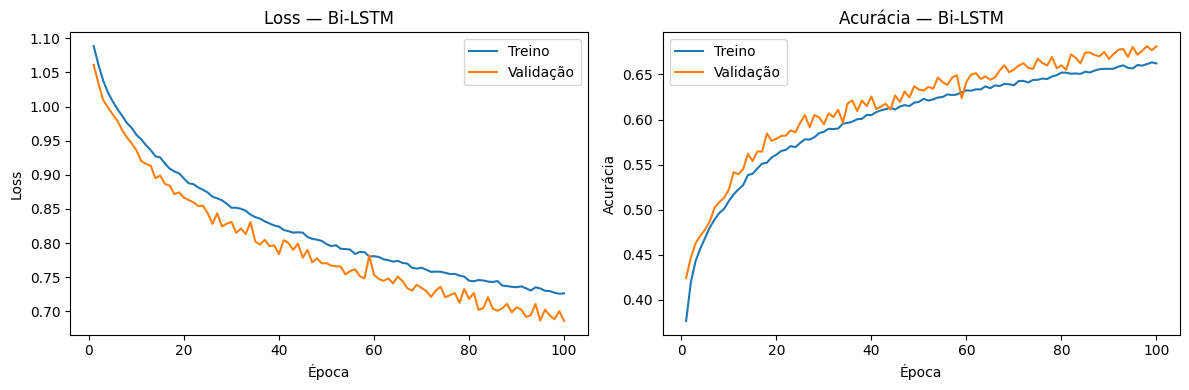

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_ran = range(1, len(lstm_result.history["loss"]) + 1)

ax1.plot(epochs_ran, lstm_result.history["loss"], label="Treino")
ax1.plot(epochs_ran, lstm_result.history["val_loss"], label="Validação")
ax1.set_title("Loss — Bi-LSTM")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(epochs_ran, lstm_result.history["accuracy"], label="Treino")
ax2.plot(epochs_ran, lstm_result.history["val_accuracy"], label="Validação")
ax2.set_title("Acurácia — Bi-LSTM")
ax2.set_xlabel("Época")
ax2.set_ylabel("Acurácia")
ax2.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "lstm_learning_curves.png", dpi=150)
plt.show()

### Resultado no conjunto de teste — LSTM

In [6]:
print(f"Loss no teste:     {lstm_result.test_loss:.4f}")
print(f"Acurácia no teste: {lstm_result.test_accuracy:.4f} ({lstm_result.test_accuracy * 100:.2f}%)")

Loss no teste:     0.6958
Acurácia no teste: 0.6754 (67.54%)


### Matriz de confusão — LSTM

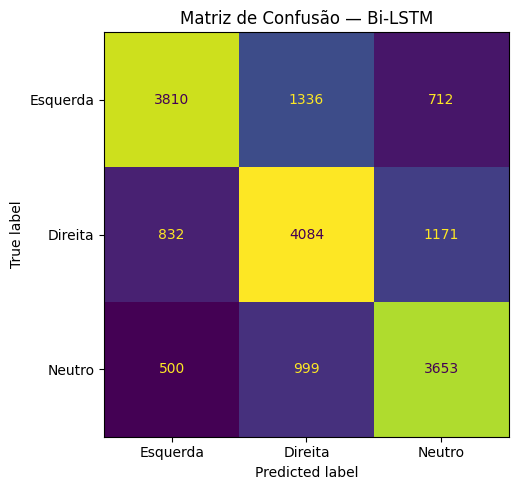

In [7]:
cm = confusion_matrix(lstm_result.y_test, lstm_result.y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Esquerda", "Direita", "Neutro"])
disp.plot(ax=ax, colorbar=False)
ax.set_title("Matriz de Confusão — Bi-LSTM")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "lstm_confusion_matrix.png", dpi=150)
plt.show()

### Relatório de classificação — LSTM

- **Precision**: de tudo que o modelo disse ser classe X, quantos eram de fato classe X.
- **Recall**: de todas as amostras da classe X, quantas o modelo acertou.
- **F1-score**: média harmônica entre precision e recall.

In [8]:
print(classification_report(lstm_result.y_test, lstm_result.y_pred, target_names=["Esquerda", "Direita", "Neutro"]))

              precision    recall  f1-score   support

    Esquerda       0.74      0.65      0.69      5858
     Direita       0.64      0.67      0.65      6087
      Neutro       0.66      0.71      0.68      5152

    accuracy                           0.68     17097
   macro avg       0.68      0.68      0.68     17097
weighted avg       0.68      0.68      0.68     17097



---
## Parte 2 — Bidirectional GRU

A GRU (Gated Recurrent Unit) é uma variante mais simples da LSTM com ~25% menos parâmetros. Usa apenas dois gates (reset e update) em vez de três (input, forget, output), convergindo mais rápido e sendo menos propensa a overfitting em datasets menores.

Usamos o **mesmo reshape** da LSTM: (N, 5_bandas, 5_canais).

In [9]:
gru_config = GRUConfig()

gru_result = train_gru(X_train, y_train, X_test, y_test, gru_config)

Epoch 1/100


  1/855 ━━━━━━━━━━━━━━━━━━━━ 41:10 3s/step - accuracy: 0.2969 - loss: 1.1070

 22/855 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3386 - loss: 1.1157  

 42/855 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3387 - loss: 1.1152

 62/855 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3383 - loss: 1.1146

...

792/855 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6521 - loss: 0.7359

811/855 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6522 - loss: 0.7359

829/855 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6522 - loss: 0.7359

848/855 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6522 - loss: 0.7360

855/855 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6541 - loss: 0.7373 - val_accuracy: 0.6864 - val_loss: 0.6746 - learning_rate: 1.2500e-04


### Curvas de aprendizado — GRU

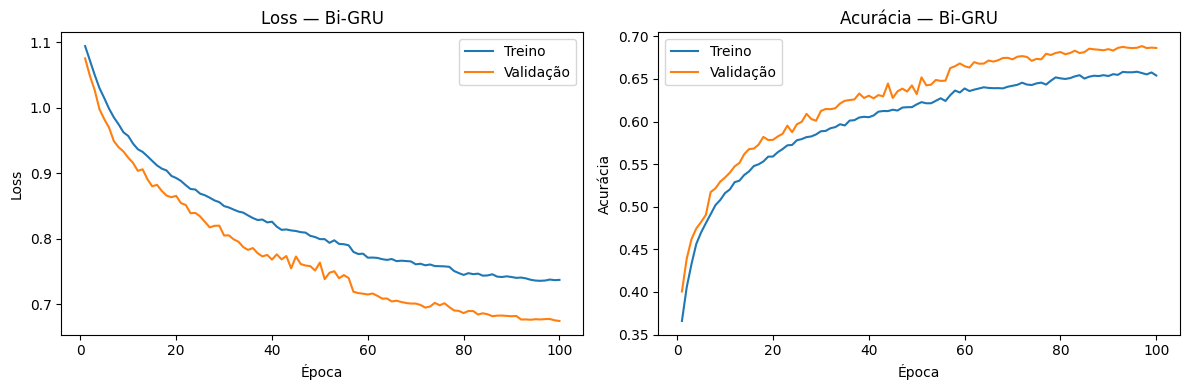

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_ran = range(1, len(gru_result.history["loss"]) + 1)

ax1.plot(epochs_ran, gru_result.history["loss"], label="Treino")
ax1.plot(epochs_ran, gru_result.history["val_loss"], label="Validação")
ax1.set_title("Loss — Bi-GRU")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(epochs_ran, gru_result.history["accuracy"], label="Treino")
ax2.plot(epochs_ran, gru_result.history["val_accuracy"], label="Validação")
ax2.set_title("Acurácia — Bi-GRU")
ax2.set_xlabel("Época")
ax2.set_ylabel("Acurácia")
ax2.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "gru_learning_curves.png", dpi=150)
plt.show()

### Resultado no conjunto de teste — GRU

In [11]:
print(f"Loss no teste:     {gru_result.test_loss:.4f}")
print(f"Acurácia no teste: {gru_result.test_accuracy:.4f} ({gru_result.test_accuracy * 100:.2f}%)")

Loss no teste:     0.6799
Acurácia no teste: 0.6843 (68.43%)


### Matriz de confusão — GRU

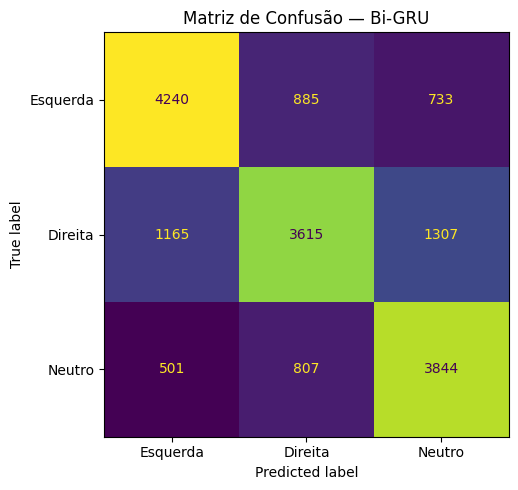

In [12]:
cm = confusion_matrix(gru_result.y_test, gru_result.y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Esquerda", "Direita", "Neutro"])
disp.plot(ax=ax, colorbar=False)
ax.set_title("Matriz de Confusão — Bi-GRU")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "gru_confusion_matrix.png", dpi=150)
plt.show()

### Relatório de classificação — GRU

In [13]:
print(classification_report(gru_result.y_test, gru_result.y_pred, target_names=["Esquerda", "Direita", "Neutro"]))

              precision    recall  f1-score   support

    Esquerda       0.72      0.72      0.72      5858
     Direita       0.68      0.59      0.63      6087
      Neutro       0.65      0.75      0.70      5152

    accuracy                           0.68     17097
   macro avg       0.68      0.69      0.68     17097
weighted avg       0.69      0.68      0.68     17097



---
## Comparação: CNN vs Bi-LSTM vs Bi-GRU

CNN baseline: **72.70%** (acurácia no teste).

In [14]:
CNN_ACCURACY = 0.7270

results = [
    ("CNN (baseline)",  CNN_ACCURACY),
    ("Bi-LSTM",         lstm_result.test_accuracy),
    ("Bi-GRU",          gru_result.test_accuracy),
]

print(f"{'Modelo':<20} {'Acurácia':>10} {'vs CNN':>10}")
print("-" * 42)
for name, acc in results:
    delta = acc - CNN_ACCURACY
    sign = "+" if delta >= 0 else ""
    print(f"{name:<20} {acc * 100:>9.2f}%  {sign}{delta * 100:>+.2f}pp")

Modelo                 Acurácia     vs CNN
------------------------------------------
CNN (baseline)           72.70%  ++0.00pp
Bi-LSTM                  67.54%  -5.16pp
Bi-GRU                   68.43%  -4.27pp


## Salvar modelos

In [15]:
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

lstm_result.model.save(MODELS_DIR / "lstm_model.keras")
print("Modelo salvo em outputs/models/lstm_model.keras")

gru_result.model.save(MODELS_DIR / "gru_model.keras")
print("Modelo salvo em outputs/models/gru_model.keras")

Modelo salvo em outputs/models/lstm_model.keras
Modelo salvo em outputs/models/gru_model.keras
